In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import os
import json
import matplotlib.pyplot as plt

# 1. 读取 JSON 文件
def load_json_files(folder_path):
    """
    加载指定文件夹下所有的 JSON 文件，返回一个 dict。
    key = 文件名, value = 解析后的 dict
    """
    results = {}
    for file in os.listdir(folder_path):
        if file.endswith(".json"):
            file_path = os.path.join(folder_path, file)
            with open(file_path, "r") as f:
                data = json.load(f)
            results[file] = data
    return results


# 2. 画图函数
def plot_metric(results, metric="avg_eer"):
    """
    输入: results = { filename: { "n": [...], "avg_eer": [...], "avg_auc": [...] } }
    metric: "avg_eer" 或 "avg_auc"
    """
    plt.figure(figsize=(10,6))
    
    for name, data in results.items():
        n = data["n"]
        y = data[metric]
        plt.plot(n, y, marker="o", label=name.replace(".json",""))

    plt.xlabel("n (number of fused scores)")
    plt.ylabel(metric.upper())
    plt.title(f"{metric.upper()} vs n")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_metric_events(results, metric="avg_eer", max_x=650, dataset = ""):
    """
    按 chunk size 排序后画图
    """
    plt.figure(figsize=(10,6))
    
    curves = []
    for name, data in results.items():
        # 提取 chunk size
        chunk_size = int(''.join([c for c in name if c.isdigit()]))
        curves.append((chunk_size, name, data))
    
    # 按 chunk size 排序
    curves.sort(key=lambda x: x[0])
    
    # 画图
    for chunk_size, name, data in curves:
        n = np.array(data["n"])
        x = n * chunk_size
        y = data[metric]
        plt.plot(x, y, marker="o", label=f"{name.replace('.json','')} (chunk={chunk_size})")

    plt.xlabel("Events")
    plt.ylabel(metric.upper())
    plt.title(f"{metric.upper()} vs Events {dataset}")
    plt.legend(title="Chunk Sizes", loc="best")
    plt.grid(True)
    plt.xlim(0, max_x)
    plt.show()



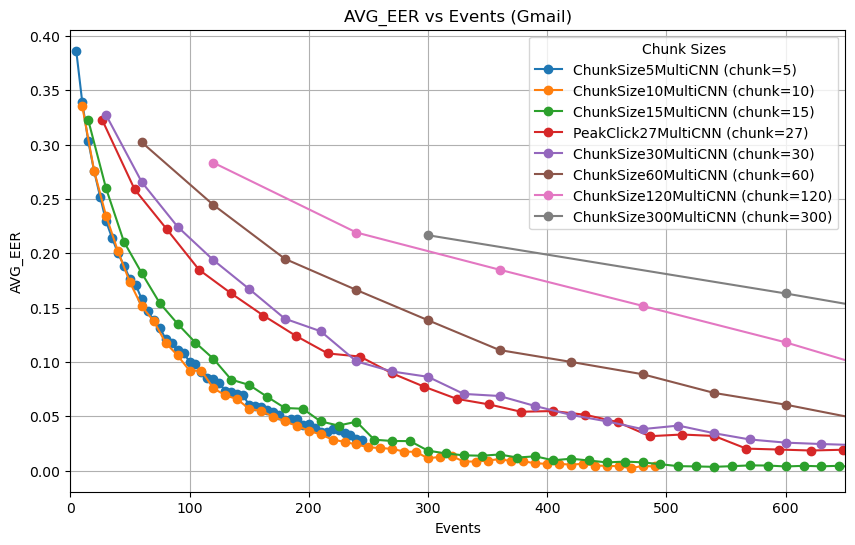

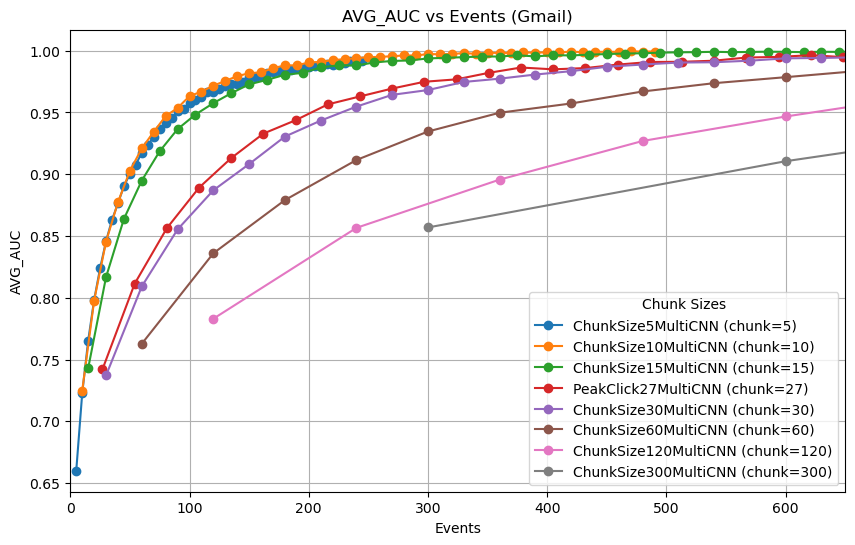

In [4]:
# 加载 Gmail 文件夹的所有 JSON
folder = "../Visualization/Chunking/Gmail"
results = load_json_files(folder)

# 画 avg_eer vs events
plot_metric_events(results, metric="avg_eer", dataset = "(Gmail)")

# 画 avg_auc vs events
plot_metric_events(results, metric="avg_auc", dataset = "(Gmail)")



In [5]:
import seaborn as sns

def plot_first_avg_eer_bar(results, dataset = ""):
    """
    绘制 bar chart，每个 JSON 文件取第一个 avg_eer
    X 轴为离散 chunk size，每个 bar 不同颜色
    """
    chunk_sizes = []
    first_eers = []
    
    for name, data in results.items():
        # 提取 chunk size
        chunk_size = int(''.join([c for c in name if c.isdigit()]))
        first_eer = data["avg_eer"][0]  # 取第一个值
        chunk_sizes.append(chunk_size)
        first_eers.append(first_eer)
    
    # 按 chunk size 排序
    sorted_pairs = sorted(zip(chunk_sizes, first_eers), key=lambda x: x[0])
    chunk_sizes, first_eers = zip(*sorted_pairs)
    
    # 画图
    plt.figure(figsize=(8,6))
    colors = sns.color_palette("tab10", len(chunk_sizes))  # 不同颜色
    
    bars = plt.bar(range(len(chunk_sizes)), first_eers, 
                   color=colors, edgecolor="black")
    
    plt.xticks(range(len(chunk_sizes)), chunk_sizes)  # X 轴显示 chunk size
    plt.xlabel("Chunk Size")
    plt.ylabel("First AVG_EER (n=1)")
    plt.title(f"First AVG_EER vs Chunk Size {dataset}")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    
    # 在柱子上标数值
    for x, y in zip(range(len(chunk_sizes)), first_eers):
        plt.text(x, y+0.005, f"{y:.3f}", ha="center", fontsize=9)
    
    plt.show()



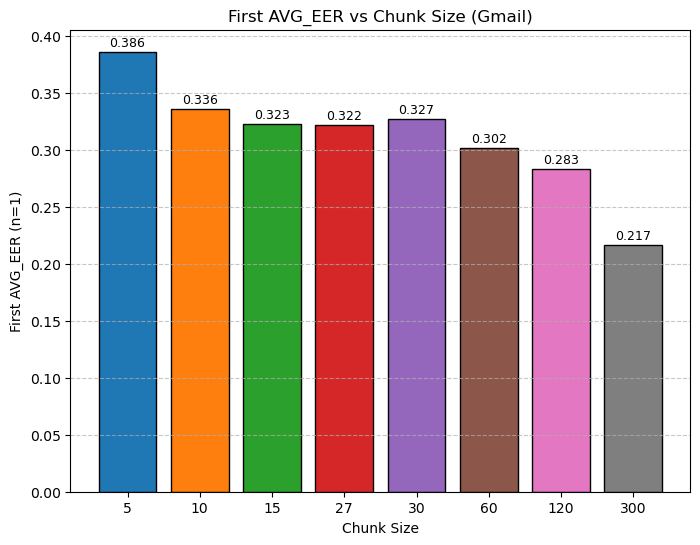

In [6]:
plot_first_avg_eer_bar(results, dataset="(Gmail)")

In [7]:
MuliCNN_Gmail_PeakClick = [
    0.3120837939062417, 0.2471879654964245, 0.20479500843424994, 0.17015840689260187,
    0.14798844804536257, 0.11773567628249078, 0.10555864518953763, 0.08769902675152652,
    0.0807682081029029, 0.06661772485490679, 0.06169033719014209, 0.04891830773871839,
    0.04701265510884007, 0.03847297453954682, 0.03234671424497235, 0.03187610023955038,
    0.025647571492677882, 0.02480035891106727, 0.022036985351311916, 0.018437194261785767,
    0.011625154435942172, 0.011795411321205308, 0.008629378377073607, 0.013199667867498628,
    0.0093782779822023, 0.006507157563741415, 0.005505187101097945, 0.0025919955839033716,
    0.005409782841085046, 0.005587289464841095, 0.004348030814002147, 0.004235555650782719,
    0.0008522894871504782, 0.001565684225055802, 0.002201660142985338, 0.002774629728141703,
    0.004230160300856091, 0.0044140103073607335, 0.004032258064516129, 0.001664380500369529,
    0.0004388852315673103, 0.00022558087077907425, 0.00023041474656122277, 0.0004564059723239023,
    0.0, 0.0, 0.00024254183847600218, 0.0004888707826454255, 0.00050403225812636
]

MuliCNN_Gmail_Trajectory = [
    0.3368004777633533, 0.27281948247499593, 0.23016561965776638, 0.20079768858906225,
    0.1726914953657674, 0.15594554387467943, 0.13914352431722446, 0.11752122906329383,
    0.10333436014667108, 0.09185400193436673, 0.08679083585854207, 0.07358775608136882,
    0.06525714570071037, 0.056932973532559876, 0.05144945708602869, 0.04795819872799047,
    0.04465775865780285, 0.04070352093779718, 0.037329111138006306, 0.03285582215790896,
    0.03025712904364765, 0.028075621242080222, 0.02302658297447889, 0.023657300270990177,
    0.021252662506606255, 0.019407369799195485, 0.013874508609338539, 0.016431286059413526,
    0.011778995848934024, 0.011120116217686408, 0.009950132733863682, 0.010906738222175765,
    0.009035072270395164, 0.00841440585669386, 0.004690340755650306, 0.00856020269183669,
    0.008836186336767088, 0.007369173214643895, 0.005689834655974048, 0.0034956217051369228,
    0.003195200965803621, 0.004418212331379997, 0.004386448683771749, 0.0038446953032897275,
    0.0030652416554541938, 0.0038070781252212164, 0.0037693568611603663, 0.0028594657881061015,
    0.0010857622265685776
]

MultiCNN_Balabit_PeakClick = [0.253677, 0.173535, 0.132252, 0.0987, 0.079215, 0.063793, 0.04741, 0.035503, 
 0.029278, 0.02379, 0.020755, 0.01731, 0.011247, 0.01124, 0.008421, 0.00742, 
 0.004174, 0.004061, 0.00435, 0.001872, 0.003557, 0.002577, 0.00177, 0.0007, 
 0.000887, 0.000303, 0.000486, 0.000504, 0.00017, 0.001065, 0.000197, 0.000185, 
 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
 0.000261, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

MultiCNN_Balabit_Trajectory = [0.254812, 0.17532, 0.13491, 0.107566, 0.084616, 0.071507, 0.057954, 0.048267, 
 0.042066, 0.032962, 0.031386, 0.023808, 0.021322, 0.018099, 0.01743, 0.015098, 
 0.00867, 0.007967, 0.008468, 0.006853, 0.004828, 0.003733, 0.004459, 0.003719, 
 0.003686, 0.003723, 0.002537, 0.00059, 0.001388, 0.000201, 0.000622, 0.000214, 
 0.000442, 0.000227, 0.0, 0.000482, 0.0, 0.0, 0.0, 0.0, 
 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]



In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_four_curves_events(MuliCNN_Gmail_PeakClick, MuliCNN_Gmail_Trajectory,
                            MultiCNN_Balabit_PeakClick, MultiCNN_Balabit_Trajectory,
                            scale_gmail_peak=26.9, scale_gmail_traj=16.3,
                            scale_balabit_peak=19.3, scale_balabit_traj=25.22,
                            max_x=650, model = ""):
    """
    画 4 条曲线, x = events = n * scale_factor
    y = avg_eer
    """
    plt.figure(figsize=(10,6))

    # Gmail PeakClick
    n1 = np.arange(1, len(MuliCNN_Gmail_PeakClick)+1)
    x1 = n1 * scale_gmail_peak
    plt.plot(x1, MuliCNN_Gmail_PeakClick, marker="o", label="Gmail PeakClick")

    # Gmail Trajectory
    n2 = np.arange(1, len(MuliCNN_Gmail_Trajectory)+1)
    x2 = n2 * scale_gmail_traj
    plt.plot(x2, MuliCNN_Gmail_Trajectory, marker="s", label="Gmail Trajectory")

    # Balabit PeakClick
    n3 = np.arange(1, len(MultiCNN_Balabit_PeakClick)+1)
    x3 = n3 * scale_balabit_peak
    plt.plot(x3, MultiCNN_Balabit_PeakClick, marker="^", label="Balabit PeakClick")

    # Balabit Trajectory
    n4 = np.arange(1, len(MultiCNN_Balabit_Trajectory)+1)
    x4 = n4 * scale_balabit_traj
    plt.plot(x4, MultiCNN_Balabit_Trajectory, marker="d", label="Balabit Trajectory")

    # 设置图形
    plt.xlabel("Events")
    plt.ylabel("AVG_EER")
    plt.title(f"AVG_EER vs Events (Gmail & Balabit) {model}")
    plt.legend()
    plt.grid(True)
    plt.xlim(0, max_x)   # 限制 x 轴范围
    plt.show()



Avg length for each dataset and segmentation method:

Balabit Trajecotry: 25.22

Balabit PeakClick: 19.3

Gmail Trajectory: 16.3

Gmail PeakClick: 26.9

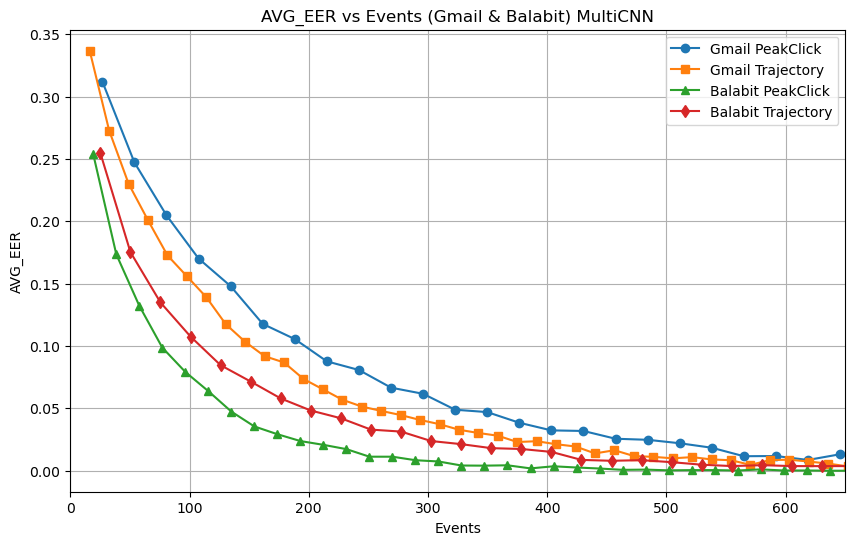

In [9]:
plot_four_curves_events(MuliCNN_Gmail_PeakClick, MuliCNN_Gmail_Trajectory,
                 MultiCNN_Balabit_PeakClick, MultiCNN_Balabit_Trajectory, model="MultiCNN")


In [10]:
SingleCNN_Gmail_PeakClick = [0.376221, 0.348451, 0.31224, 0.288267, 0.264058, 0.244832, 0.21985, 0.202958, 
 0.210999, 0.196232, 0.186812, 0.181012, 0.154029, 0.143619, 0.163904, 0.148019, 
 0.14842, 0.140619, 0.128613, 0.126862, 0.101301, 0.103019, 0.098541, 0.099185, 
 0.079832, 0.085788, 0.088751, 0.096196, 0.099188, 0.098508, 0.070992, 0.063891, 
 0.084316, 0.066478, 0.070457, 0.090478, 0.057732, 0.058841, 0.052434, 0.057752, 
 0.039646, 0.046158, 0.04274, 0.041944, 0.055306, 0.049697, 0.05085, 0.039136, 
 0.032662]

SingleCNN_Gmail_Trajectory = [
    0.3866007235086349, 0.35735666581377745, 0.3283938615890666, 0.3068472552590944,
    0.2895890973546855, 0.27252846088032484, 0.2617787721421612, 0.24700441040480495,
    0.23213396725340568, 0.22109919776173326, 0.22551980941075794, 0.20634689127303765,
    0.2059288924188382, 0.192196118333731, 0.1880655778623407, 0.1876744091146834,
    0.16857710431878112, 0.16304348377022798, 0.15943006625380807, 0.15313488249787088,
    0.1408592939735253, 0.15164056721933494, 0.12640296451162655, 0.12771181721801922,
    0.12786496187566612, 0.12153511887271738, 0.11694671385331278, 0.11274605127022445,
    0.11178626569228287, 0.11072132011753594, 0.1088921989102073, 0.1017460055126368,
    0.09046620196164133, 0.09011318853416524, 0.09857107034500523, 0.07789167943973116,
    0.07960069938524418, 0.07841425724153019, 0.0744245377522026, 0.08238930896209493,
    0.08069650156598805, 0.0766145667163124, 0.07081101366590006, 0.06349861886871065,
    0.05837118278963444, 0.050861786748284475, 0.056220731186581226, 0.06460379903119332,
    0.05242422334140047
]


SingleCNN_Balabit_PeakClick = [0.282405, 0.218738, 0.17228, 0.14042, 0.119656, 0.1015, 0.083152, 0.071225, 
 0.062561, 0.052972, 0.049029, 0.045804, 0.038972, 0.030486, 0.031386, 0.029085, 
 0.022138, 0.020875, 0.021168, 0.016463, 0.013423, 0.01855, 0.013651, 0.008666, 
 0.008808, 0.007341, 0.005299, 0.006298, 0.007619, 0.006586, 0.003799, 0.00285, 
 0.002071, 0.000432, 0.005146, 0.003495, 0.001392, 0.000966, 0.000496, 0.000509, 
 0.000521, 0.0, 0.000546, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

SingleCNN_Balabit_Trajectory = [
    0.32737052225072244, 0.26553623845937757, 0.22453305861673853, 0.1938515537934583,
    0.16726638309711622, 0.13989494061521074, 0.12834418883322862, 0.10060808291117204,
    0.09130832167810495, 0.08642493519926103, 0.0706871260270886, 0.06876608610460658,
    0.05950859619564915, 0.051360659161958054, 0.045424266500755914, 0.0382981117306077,
    0.041528413690256255, 0.034504624886619005, 0.028745754751442462, 0.025842099656749183,
    0.02455772020213742, 0.023540773984228512, 0.019315365563906096, 0.016883696728887943,
    0.016069409727335515, 0.014347610240271412, 0.00858120264541004, 0.007114265626662219,
    0.005594520428123178, 0.005841787891169282, 0.0068618770762468966, 0.004343144133420992,
    0.004814013307852722, 0.003180592249568305, 0.0018708093201942947, 0.0015390676690979098,
    0.0028777066835203786, 0.0032967653829695017, 0.0026147311319870566, 0.0008960573476952139,
    0.0006832989035745294, 0.00022401433695666084, 0.00024254183848239973, 0.0026881720430083763,
    0.002932551319647911, 0.0029325513196480934, 0.0, 0.0, 0.0002757099531344208
]





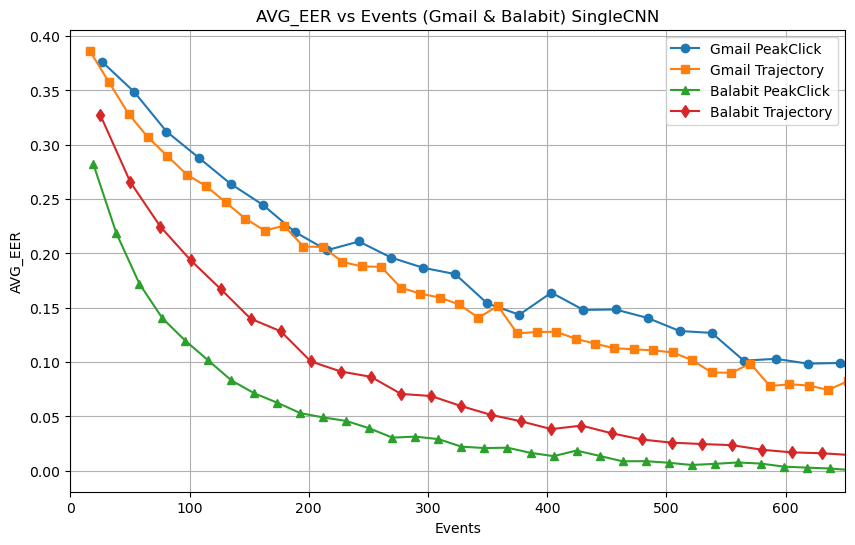

In [11]:
plot_four_curves_events(SingleCNN_Gmail_PeakClick, SingleCNN_Gmail_Trajectory,
                 SingleCNN_Balabit_PeakClick, SingleCNN_Balabit_Trajectory, model="SingleCNN")

**Balabit**

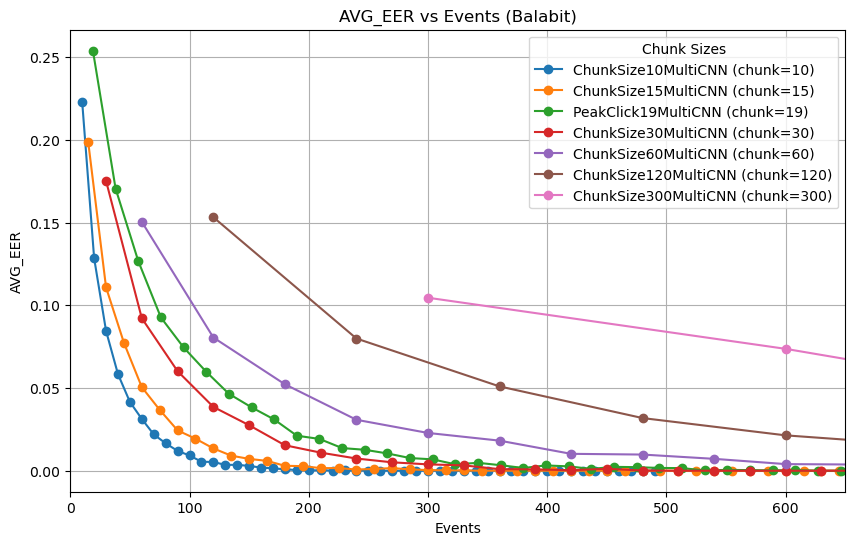

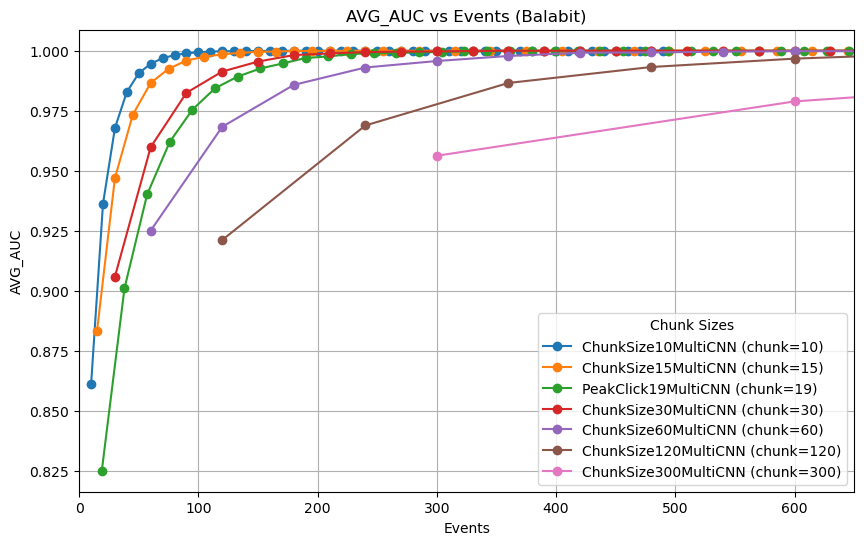

In [12]:
# 加载 Gmail 文件夹的所有 JSON
folder = "../Visualization/Chunking/Balabit"
results = load_json_files(folder)

# 画 avg_eer vs events
plot_metric_events(results, metric="avg_eer", dataset = "(Balabit)")

# 画 avg_auc vs events
plot_metric_events(results, metric="avg_auc", dataset = "(Balabit)")


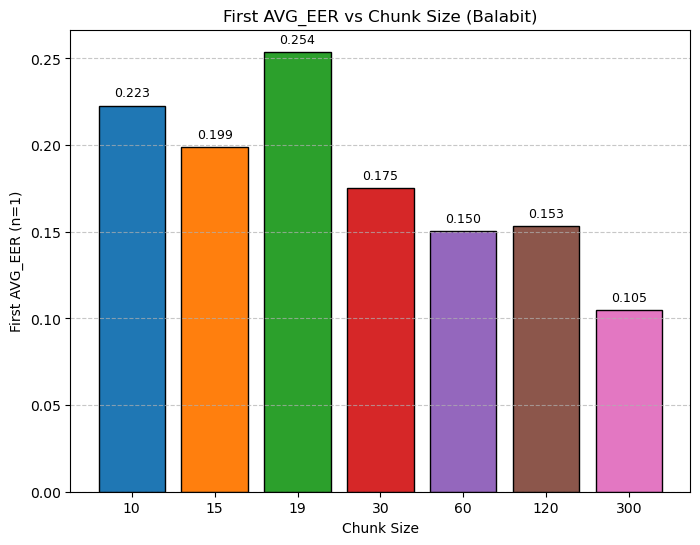

In [13]:
plot_first_avg_eer_bar(results, dataset="(Balabit)")

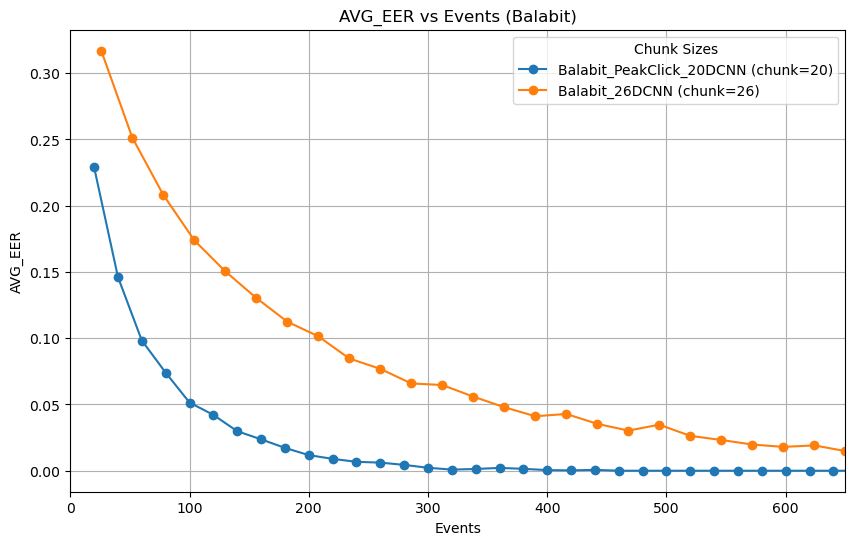

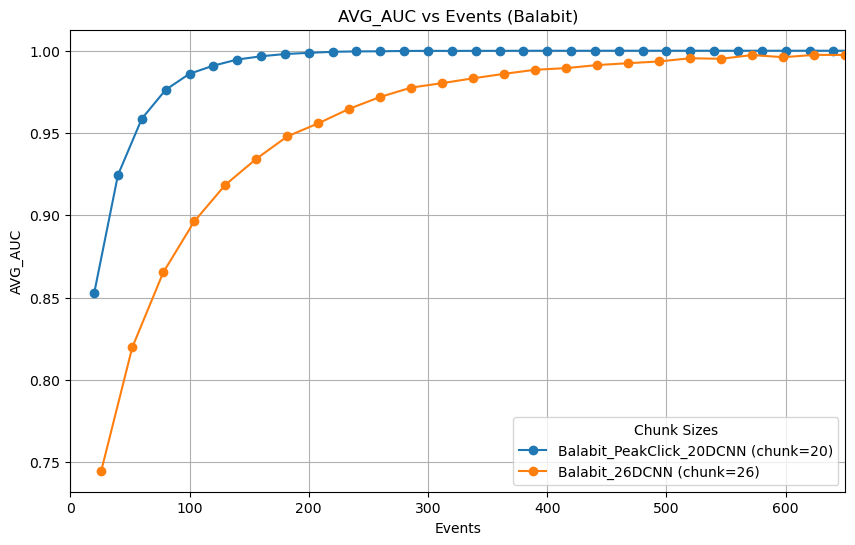

In [14]:
# 加载 Gmail 文件夹的所有 JSON
folder = "../Visualization/1DCNN"
results = load_json_files(folder)

# 画 avg_eer vs events
plot_metric_events(results, metric="avg_eer", dataset = "(Balabit)")

# 画 avg_auc vs events
plot_metric_events(results, metric="avg_auc", dataset = "(Balabit)")